In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [15]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,learning_curve
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from skimage.feature import (
    hog,
    local_binary_pattern
)

from skimage import exposure

In [2]:
dataset_path = "/kaggle/input/datasets/prateekbaliyan/tomato-apple"

IMG_SIZE = 256

In [3]:
# =====================================================
# FEATURE EXTRACTION
# =====================================================

def extract_features(img):

    features = []

    # -------------------------------------------------
    # RESIZE
    # -------------------------------------------------

    img = cv2.resize(img, (256,256))

    # -------------------------------------------------
    # HSV CONVERSION
    # -------------------------------------------------

    hsv = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2HSV
    )

    # -------------------------------------------------
    # GRAYSCALE
    # -------------------------------------------------

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    # -------------------------------------------------
    # HSV HISTOGRAM
    # -------------------------------------------------

    hist = cv2.calcHist(
        [hsv],
        [0],
        None,
        [32],
        [0,180]
    )

    hist = hist.astype("float32")

    hist /= (hist.sum() + 1e-6)

    features.extend(hist.flatten())

    # -------------------------------------------------
    # LBP FEATURES
    # -------------------------------------------------

    radius = 1

    n_points = 8 * radius

    lbp = local_binary_pattern(
        gray,
        n_points,
        radius,
        method="uniform"
    )

    lbp_hist, _ = np.histogram(
        lbp.ravel(),
        bins=10,
        range=(0,10)
    )

    lbp_hist = lbp_hist.astype("float32")

    lbp_hist /= (lbp_hist.sum() + 1e-6)

    features.extend(lbp_hist)

    # -------------------------------------------------
    # EDGE DETECTION
    # -------------------------------------------------

    edges = cv2.Canny(
        gray,
        100,
        200
    )

    edge_count = np.sum(edges > 0)

    features.append(edge_count)

    # -------------------------------------------------
    # SHAPE FEATURES
    # -------------------------------------------------

    contours, _ = cv2.findContours(
        edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    area = sum(
        cv2.contourArea(c)
        for c in contours
    )

    perimeter = sum(
        cv2.arcLength(c, True)
        for c in contours
    )

    area = np.clip(area, 0, 1e5)

    perimeter = np.clip(perimeter, 0, 1e4)

    circularity = (
        4 * np.pi * area
    ) / (perimeter**2 + 1e-6)

    features.extend([
        area,
        perimeter,
        circularity
    ])

    # -------------------------------------------------
    # HOG FEATURES
    # -------------------------------------------------

    hog_features, hog_image = hog(
        gray,
        orientations=8,
        pixels_per_cell=(16,16),
        cells_per_block=(2,2),
        visualize=True
    )

    features.extend(hog_features[:100])

    return np.array(
        features,
        dtype=np.float32
    )

In [4]:
# =====================================================
# IMAGE AUGMENTATION
# =====================================================

def augment_image(img):

    augmented = []

    # ORIGINAL

    augmented.append(img)

    # -------------------------------------------------
    # FLIP
    # -------------------------------------------------

    flip = cv2.flip(img, 1)

    augmented.append(flip)

    # -------------------------------------------------
    # BRIGHTNESS
    # -------------------------------------------------

    bright = cv2.convertScaleAbs(
        img,
        alpha=1,
        beta=50
    )

    augmented.append(bright)

    # -------------------------------------------------
    # CONTRAST
    # -------------------------------------------------

    contrast = cv2.convertScaleAbs(
        img,
        alpha=1.5,
        beta=0
    )

    augmented.append(contrast)

    # -------------------------------------------------
    # ROTATION
    # -------------------------------------------------

    h, w = img.shape[:2]

    matrix = cv2.getRotationMatrix2D(
        (w//2, h//2),
        45,
        1
    )

    rotated = cv2.warpAffine(
        img,
        matrix,
        (w, h)
    )

    augmented.append(rotated)

    # -------------------------------------------------
    # SPATIAL FILTERING
    # -------------------------------------------------

    filtered = cv2.bilateralFilter(
        img,
        9,
        75,
        75
    )

    augmented.append(filtered)

    return augmented


In [5]:
# =====================================================
# LOAD DATASET
# =====================================================

X = []
y = []

classes = os.listdir(dataset_path)

print("Classes :", classes)

for label, class_name in enumerate(classes):

    class_path = os.path.join(
        dataset_path,
        class_name
    )

    if not os.path.isdir(class_path):
        continue

    print("\nReading :", class_name)

    for file in os.listdir(class_path):

        img_path = os.path.join(
            class_path,
            file
        )

        try:

            img = cv2.imread(img_path)

            # CORRUPTED IMAGE CHECK

            if img is None:

                print(
                    "Corrupted Image :",
                    img_path
                )

                continue

            # RESIZE

            img = cv2.resize(
                img,
                (IMG_SIZE, IMG_SIZE)
            )

            # AUGMENTATION

            augmented_images = augment_image(img)

            for aug_img in augmented_images:

                features = extract_features(
                    aug_img
                )

                X.append(features)

                y.append(label)

        except:

            continue

Classes : ['Tomato', 'Apple']

Reading : Tomato
Corrupted Image : /kaggle/input/datasets/prateekbaliyan/tomato-apple/Tomato/Training_corrupt_Tomato 11_100_100.jpg
Corrupted Image : /kaggle/input/datasets/prateekbaliyan/tomato-apple/Tomato/Training_corrupt_Tomato 10_r0_0_100.jpg

Reading : Apple
Corrupted Image : /kaggle/input/datasets/prateekbaliyan/tomato-apple/Apple/Training_corrupt_Apple 11_r0_0_100.jpg
Corrupted Image : /kaggle/input/datasets/prateekbaliyan/tomato-apple/Apple/Training_corrupt_Apple 10_r0_0_100.jpg


In [6]:
# =====================================================
# NUMPY ARRAY
# =====================================================

X = np.array(X)

y = np.array(y)

print("\nTotal Samples :", len(X))


Total Samples : 606


In [7]:
# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
# =====================================================
# FEATURE SCALING
# =====================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [17]:
models = {

    "SVM": SVC(
        C=10,
        kernel='rbf',
        gamma='scale',
        probability=True
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        weights='distance'
    )

}

In [18]:
best_model = None

best_accuracy = 0

best_name = ""

# =====================================================
# TRAINING
# =====================================================

for name, model in models.items():

    print("\nTraining :", name)

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(X_test)

    acc = accuracy_score(
        y_test,
        pred
    )

    print(name, "Accuracy :", acc)

    if acc > best_accuracy:

        best_accuracy = acc

        best_model = model

        best_name = name


Training : SVM
SVM Accuracy : 0.9262295081967213

Training : Random Forest
Random Forest Accuracy : 0.9836065573770492

Training : KNN
KNN Accuracy : 0.7704918032786885


In [19]:
# =====================================================
# FINAL RESULT
# =====================================================

print("\nBest Model :", best_name)

print("Best Accuracy :", best_accuracy)

y_pred = best_model.predict(X_test)

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)



Best Model : Random Forest
Best Accuracy : 0.9836065573770492

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        46
           1       0.97      1.00      0.99        76

    accuracy                           0.98       122
   macro avg       0.99      0.98      0.98       122
weighted avg       0.98      0.98      0.98       122



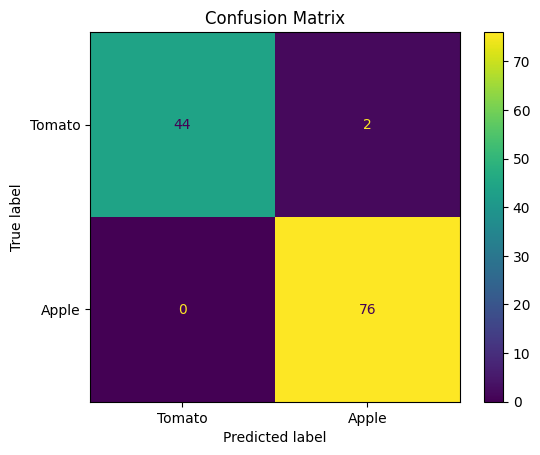

In [20]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

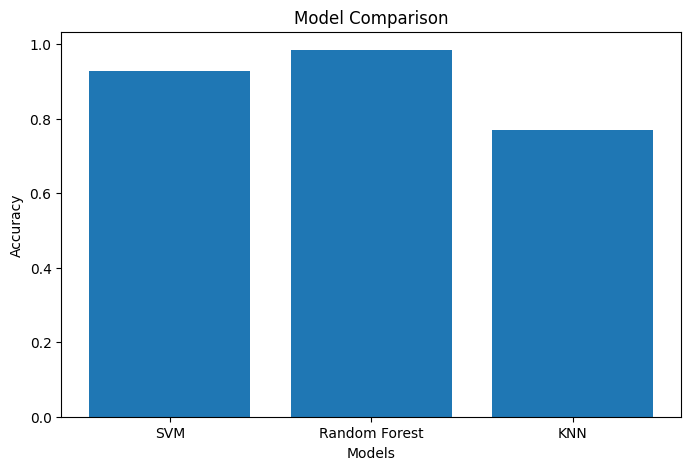

In [21]:
model_names = []

accuracies = []

for name, model in models.items():

    pred = model.predict(X_test)

    acc = accuracy_score(
        y_test,
        pred
    )

    model_names.append(name)

    accuracies.append(acc)

plt.figure(figsize=(8,5))

plt.bar(
    model_names,
    accuracies
)

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()


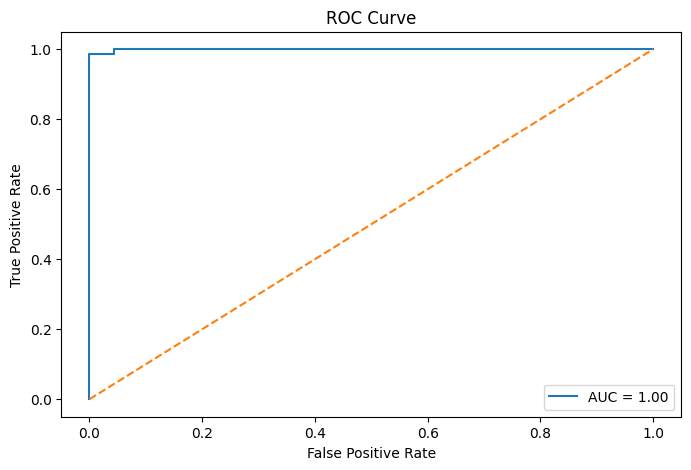

In [22]:
if len(classes) == 2:

    y_score = best_model.predict_proba(X_test)[:,1]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_score
    )

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8,5))

    plt.plot(
        fpr,
        tpr,
        label=f"AUC = {roc_auc:.2f}"
    )

    plt.plot(
        [0,1],
        [0,1],
        linestyle='--'
    )

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve")

    plt.legend()

    plt.show()


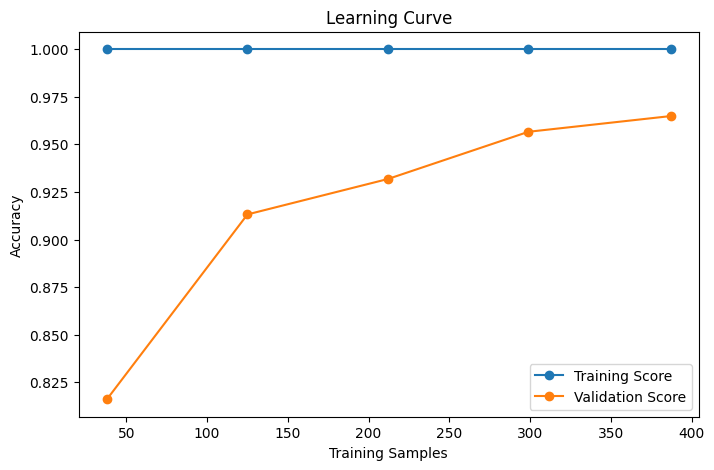

In [23]:
# =====================================================
# LEARNING CURVE
# =====================================================

train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

train_mean = np.mean(
    train_scores,
    axis=1
)

test_mean = np.mean(
    test_scores,
    axis=1
)

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Training Score'
)

plt.plot(
    train_sizes,
    test_mean,
    marker='o',
    label='Validation Score'
)

plt.xlabel("Training Samples")

plt.ylabel("Accuracy")

plt.title("Learning Curve")

plt.legend()

plt.show()